In [2]:
import pandas as pd

demo=pd.read_csv('preprocdata/demographics.csv')
print(demo.head())

   age  sex  dataset  atlas  group  outlier_index
0    0    0        1      1      1              0
1    0    0        1      1      1              0
2    0    0        1      1      1              0
3    0    1        1      1      1              0
4    0    0        1      1      1              0


In [3]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

mat = scipy.io.loadmat('preprocdata/all_data.mat')
data_struct = mat['all_data'][0, 0]
connectomes = data_struct['connectomes'] 

print(f"✅ Matrices encontradas: {connectomes.shape}")
print(f"   (Sujetos: {connectomes.shape[0]}, Regiones: {connectomes.shape[1]})")


✅ Matrices encontradas: (4216, 90, 90)
   (Sujetos: 4216, Regiones: 90)


In [4]:
def calculate_disparity(connectomes):

    # Preparamos array para guardar la media de Y por sujeto
    disparities = np.zeros(connectomes.shape[0])
    
    for i in range(connectomes.shape[0]):
        # Coger matriz del sujeto i
        adj = connectomes[i]
        
        # Asegurar diagonal a 0 (self-loops)
        np.fill_diagonal(adj, 0)
        
        # Calcular Strength (suma de pesos por nodo)
        strength = adj.sum(axis=1)
        
        # Evitar división por cero (nodos desconectados)
        valid = strength > 0
        
        # Fórmula de Disparidad Nodal: Y_i = sum((w_ij / s_i)^2)
        # (Suma de los cuadrados de los pesos normalizados)
        if np.any(valid):
            # Vectorizamos el cálculo para las 90 regiones
            nodal_Y = np.sum((adj[valid] / strength[valid, None])**2, axis=1)
            disparities[i] = nodal_Y.mean()
        else:
            disparities[i] = 0 # Caso raro: cerebro desconectado
    print(f"✅ Cálculo terminado. Media Global Y: {disparities.mean():.4f}")
    return disparities



disparities = calculate_disparity(connectomes)


✅ Cálculo terminado. Media Global Y: 0.2133


In [5]:
print(len(disparities))
print(len(demo))

data = pd.DataFrame({
    'Subject': np.arange(connectomes.shape[0]),
    'Disparity_Y': disparities
})

data = pd.concat([data, demo], axis=1)


4216
4216


<Axes: xlabel='Disparity_Y', ylabel='Count'>

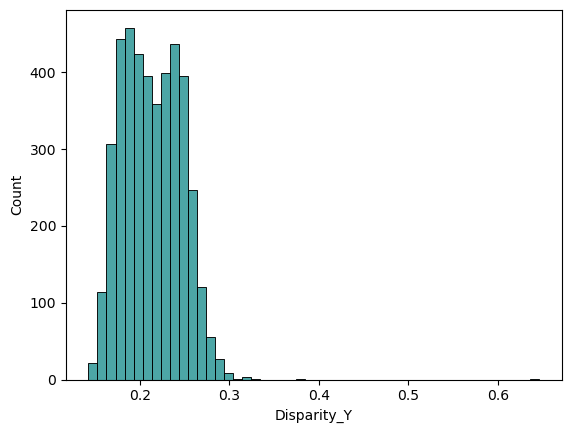

In [6]:
import seaborn as sns

sns.histplot(data['Disparity_Y'], bins=50, color='teal', alpha=0.7, edgecolor='black')


In [7]:
#print number of subjects per group
group_counts = data['age'].value_counts().sort_index()
print("Número de sujetos por grupo:")
print(group_counts)

Número de sujetos por grupo:
age
0     447
1      73
2      91
3       8
4       2
     ... 
86     12
87      9
88      6
89      7
90      4
Name: count, Length: 91, dtype: int64


Correlación entre edad y disparidad: r=0.8171, p=5.2514e-23


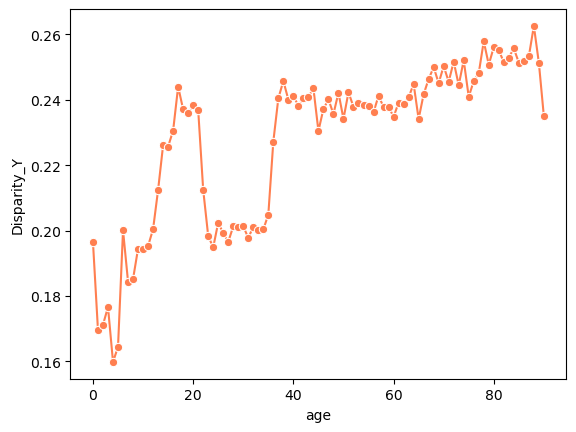

In [8]:
import scipy.stats as stats
data_age=data.groupby('age')['Disparity_Y'].mean().reset_index()
sns.lineplot(x='age', y='Disparity_Y', data=data_age, marker='o', color='coral')

# Calcular correlación entre edad y disparidad

r, p= stats.pearsonr(data_age['age'], data_age['Disparity_Y'])
print(f"Correlación entre edad y disparidad: r={r:.4f}, p={p:.4e}")

Looks like we should restrict ourselves to different datasets  maybe? 

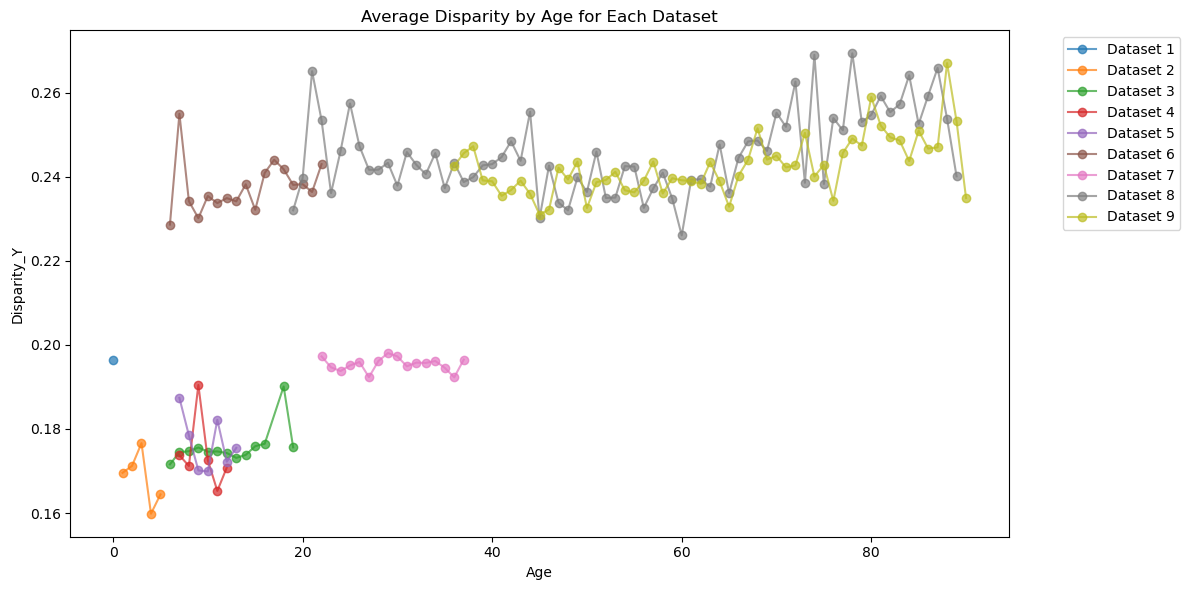

In [9]:
data_dataset = data.groupby(['dataset', 'age'])['Disparity_Y'].mean().reset_index()

# Get unique datasets
datasets = data_dataset['dataset'].unique()

# Create lineplot for each dataset
plt.figure(figsize=(12, 6))
for dataset_id in datasets:
    dataset_subset = data_dataset[data_dataset['dataset'] == dataset_id]
    plt.plot(dataset_subset['age'], dataset_subset['Disparity_Y'], marker='o', label=f'Dataset {dataset_id}', alpha=0.7)

plt.xlabel('Age')
plt.ylabel('Disparity_Y')
plt.title('Average Disparity by Age for Each Dataset')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

I'll try to remove outliers

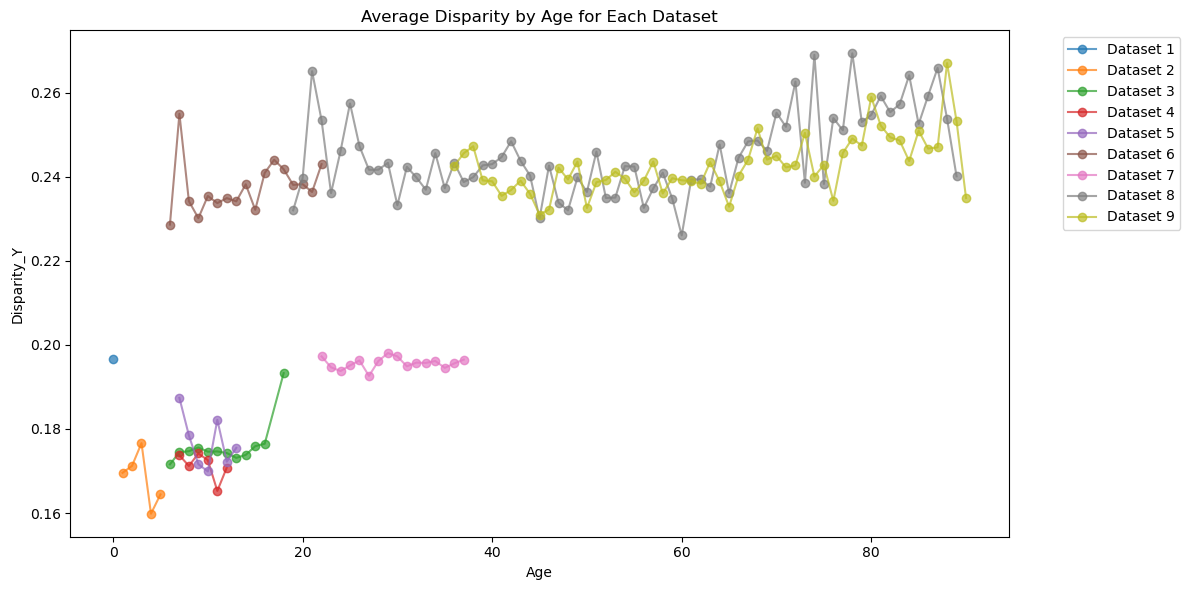

In [10]:
data_withoutoutliers=data[data['outlier_index'] == 0]
data_dataset = data_withoutoutliers.groupby(['dataset', 'age'])['Disparity_Y'].mean().reset_index()

# Get unique datasets
datasets = data_dataset['dataset'].unique()

# Create lineplot for each dataset
plt.figure(figsize=(12, 6))
for dataset_id in datasets:
    dataset_subset = data_dataset[data_dataset['dataset'] == dataset_id]
    plt.plot(dataset_subset['age'], dataset_subset['Disparity_Y'], marker='o', label=f'Dataset {dataset_id}', alpha=0.7)

plt.xlabel('Age')
plt.ylabel('Disparity_Y')
plt.title('Average Disparity by Age for Each Dataset')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
print(len(data),len(data_withoutoutliers))

4216 4202


Voy a probar a hacer la harmonización para eliminar batch effects (falta revisar, le pido a gemini que adapte el codigo de ella a python)

In [12]:
#from neuroCombat import neuroCombat
#puedo usar neuroCombat o coger directamente los datos de la autora harmonizados.

from pymatreader import read_mat
connectomes_harm = read_mat('preprocdata/harmonized_data.mat')['harmonized_data']['connectomes']['controlled_density']['normalized_weighted']

c:\Users\Ale\miniconda3\envs\snakes\Lib\site-packages\pymatreader\utils.py:304: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


In [13]:
print(f"✅ Matrices encontradas: {connectomes_harm.shape}")
print(f"   (Sujetos: {connectomes_harm.shape[0]}, Regiones: {connectomes_harm.shape[1]})")

demo_harm=pd.read_csv('preprocdata/demographics_harm.csv')
print(len(demo_harm))
print(demo_harm.head())


✅ Matrices encontradas: (3802, 90, 90)
   (Sujetos: 3802, Regiones: 90)
3802
   age  sex  dataset  atlas  remove_index
0    0    0        1      1             0
1    0    0        1      1             0
2    0    0        1      1             0
3    0    1        1      1             0
4    0    0        1      1             0


In [14]:
connectomes_harm[3][:5,:5]

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.49485744, 0.        ],
       [0.        , 0.        , 0.49485744, 0.        , 0.04515367],
       [0.        , 0.        , 0.        , 0.04515367, 0.        ]])

In [15]:
disparities_harm = calculate_disparity(connectomes_harm)

data_harm = pd.DataFrame({
    'Subject': np.arange(connectomes_harm.shape[0]),
    'Disparity_Y': disparities_harm
})

data_harm = pd.concat([data_harm, demo_harm], axis=1)


✅ Cálculo terminado. Media Global Y: 0.2662


<Axes: xlabel='age', ylabel='Disparity_Y'>

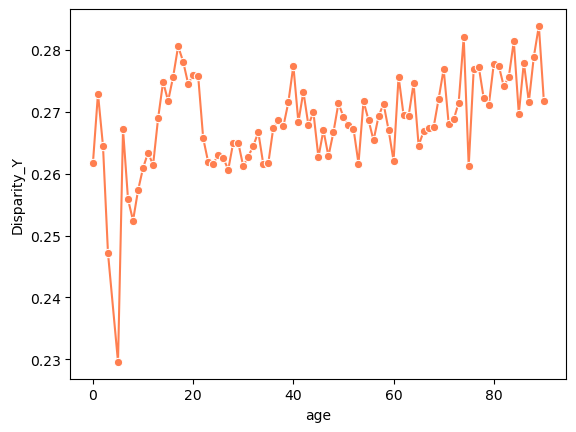

In [16]:
data_age_harm=data_harm.groupby('age')['Disparity_Y'].mean().reset_index()
sns.lineplot(x='age', y='Disparity_Y', data=data_age_harm, marker='o', color='coral')


In [17]:
data_harm.columns

Index(['Subject', 'Disparity_Y', 'age', 'sex', 'dataset', 'atlas',
       'remove_index'],
      dtype='object')

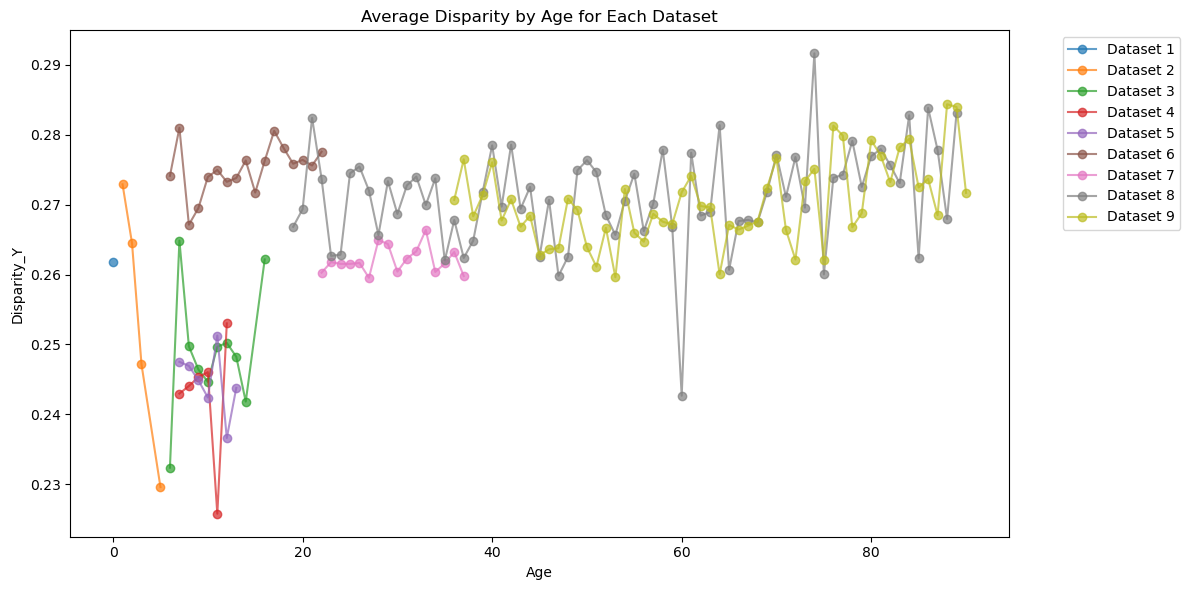

In [18]:
data_harm=data_harm[data_harm['remove_index'] == 0]
data_dataset = data_harm.groupby(['dataset', 'age'])['Disparity_Y'].mean().reset_index()

# Get unique datasets
datasets = data_dataset['dataset'].unique()

# Create lineplot for each dataset
plt.figure(figsize=(12, 6))
for dataset_id in datasets:
    dataset_subset = data_dataset[data_dataset['dataset'] == dataset_id]
    plt.plot(dataset_subset['age'], dataset_subset['Disparity_Y'], marker='o', label=f'Dataset {dataset_id}', alpha=0.7)

plt.xlabel('Age')
plt.ylabel('Disparity_Y')
plt.title('Average Disparity by Age for Each Dataset')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Igualmente no parece que el efecto sea muy grande. Voy a probar con los que tienen el mismo atlas, centrandome en bebes o en aging porque tiene mucho rango de edad. Puedo mirar a dHCP (bebés de 0 a 1 año) pero en este dataset la edad se ha perdido... podria intentar recuperarla en matlab, sino es imposible.

<Axes: xlabel='Disparity_Y', ylabel='Count'>

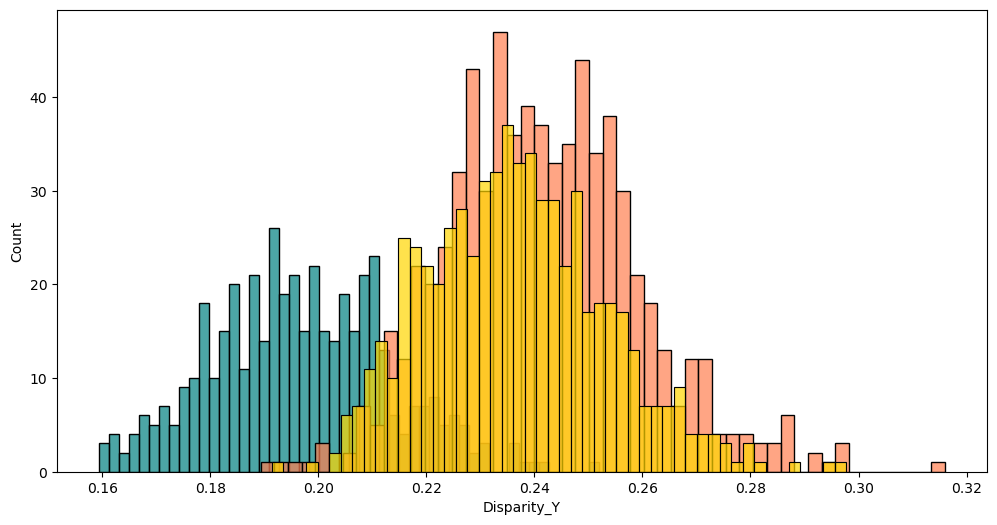

In [19]:
data_neonatal=data[data['dataset']==1] #edad 0-1, usa el mismo atlas pero no tiene info de edad ya que coge años.
#poner en el mismo gráfico neonatal y adulto
plt.figure(figsize=(12, 6)) 
data_aging=data[data['dataset']==9]
data_development=data[data['dataset']==6] #edades 5-21, usa el mismo atlas
sns.histplot(data_neonatal['Disparity_Y'], bins=50, color='teal', alpha=0.7, edgecolor='black')
sns.histplot(data_aging['Disparity_Y'], bins=50, color='coral', alpha=0.7, edgecolor='black')
sns.histplot(data_development['Disparity_Y'], bins=50, color='gold', alpha=0.7, edgecolor='black')



Neonatal dataset:
  N = 447
  Age range: 0 - 0
  Mean Disparity: 0.1965
  Cannot compute correlation (all subjects have same age)

Development dataset (ages 5-21):
  N = 633
  Age range: 6 - 22
  Pearson correlation: r = 0.1318, p = 0.0009

Aging dataset (ages 36-90):
  N = 706
  Age range: 36 - 90
  Pearson correlation: r = 0.1794, p = 0.0000



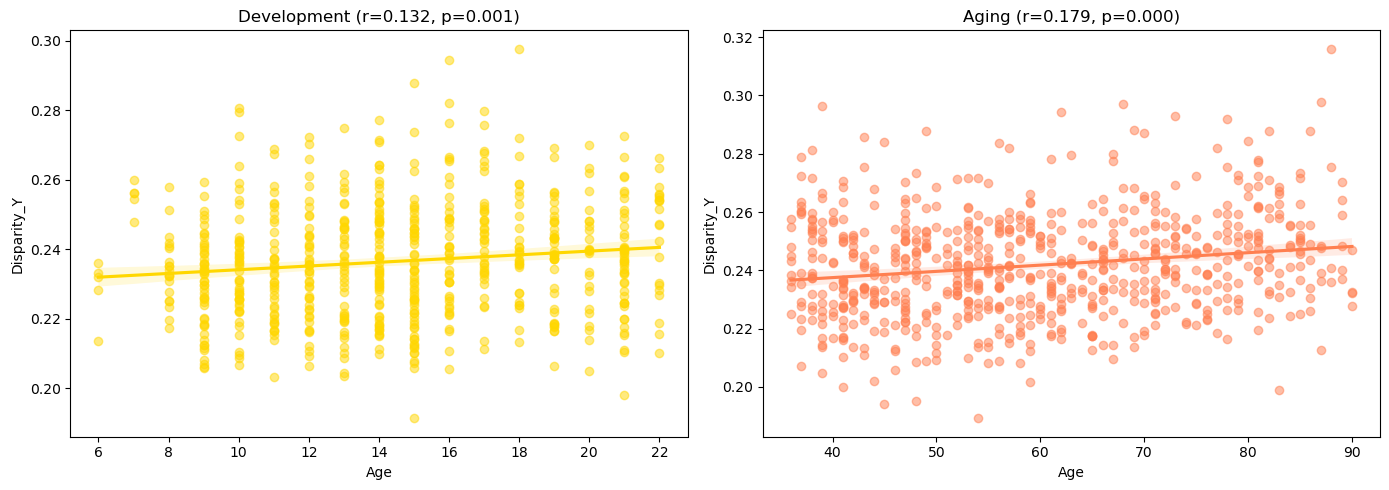

In [20]:
from scipy import stats

#ahora vamos a intentar obtener una grafica y un coeficieinte de correlación entre edad y disparidad para estos tres casos. 

# Neonatal dataset - all subjects have age=0, so correlation cannot be computed
print("Neonatal dataset:")
print(f"  N = {len(data_neonatal)}")
print(f"  Age range: {data_neonatal['age'].min()} - {data_neonatal['age'].max()}")
print(f"  Mean Disparity: {data_neonatal['Disparity_Y'].mean():.4f}")
print("  Cannot compute correlation (all subjects have same age)\n")

# Development dataset

print("Development dataset (ages 5-21):")
print(f"  N = {len(data_development)}")
print(f"  Age range: {data_development['age'].min()} - {data_development['age'].max()}")
r_dev, p_dev = stats.pearsonr(data_development['age'], data_development['Disparity_Y'])
print(f"  Pearson correlation: r = {r_dev:.4f}, p = {p_dev:.4f}\n")

# Aging dataset
print("Aging dataset (ages 36-90):")
print(f"  N = {len(data_aging)}")
print(f"  Age range: {data_aging['age'].min()} - {data_aging['age'].max()}")
r_aging, p_aging = stats.pearsonr(data_aging['age'], data_aging['Disparity_Y'])
print(f"  Pearson correlation: r = {r_aging:.4f}, p = {p_aging:.4f}\n")

# Plot scatter plots with regression lines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Development
axes[0].scatter(data_development['age'], data_development['Disparity_Y'], alpha=0.5, color='gold')
sns.regplot(x='age', y='Disparity_Y', data=data_development, ax=axes[0], color='gold', scatter=False)
axes[0].set_title(f'Development (r={r_dev:.3f}, p={p_dev:.3f})')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Disparity_Y')

# Aging
axes[1].scatter(data_aging['age'], data_aging['Disparity_Y'], alpha=0.5, color='coral')
sns.regplot(x='age', y='Disparity_Y', data=data_aging, ax=axes[1], color='coral', scatter=False)
axes[1].set_title(f'Aging (r={r_aging:.3f}, p={p_aging:.3f})')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Disparity_Y')

plt.tight_layout()
plt.show()

Quizás los datos harmonized de aging?


In [21]:
data_age_harm=data_harm.groupby('age')['Disparity_Y'].mean().reset_index()
r_harm, p_harm= stats.pearsonr(data_age_harm['age'], data_age_harm['Disparity_Y'])
print(f"All subjects (harmonized): r = {r_harm:.4f}, p = {p_harm:e}")

All subjects (harmonized): r = 0.5044, p = 4.005574e-07


In [22]:
        #Fit to years 0-25 and 25-90 as whole sets

data_harm_young = data_harm[(data_harm['age'] >= 0) & (data_harm['age'] <= 25)]
data_harm_old = data_harm[(data_harm['age'] > 25)]

data_harm_young=data_harm_young.groupby('age')['Disparity_Y'].mean().reset_index()
data_harm_old=data_harm_old.groupby('age')['Disparity_Y'].mean().reset_index()

r_harm_young, p_harm_young = stats.pearsonr(data_harm_young['age'], data_harm_young['Disparity_Y'])
r_harm_old, p_harm_old = stats.pearsonr(data_harm_old['age'], data_harm_old['Disparity_Y'])

print(f"Subjects 0-25 (harmonized): r = {r_harm_young:.4f}, p = {p_harm_young:.6e}")
print(f"Subjects 25-90 (harmonized): r = {r_harm_old:.4f}, p = {p_harm_old:.6e}")

Subjects 0-25 (harmonized): r = 0.4314, p = 3.128678e-02
Subjects 25-90 (harmonized): r = 0.6514, p = 4.195668e-09


In [23]:

data_dev_harm=data_harm[data_harm['dataset']==6]
data_dev_age_harm=data_dev_harm.groupby('age')['Disparity_Y'].mean().reset_index()
r_dev_harm, p_dev_harm = stats.pearsonr(data_dev_age_harm['age'], data_dev_age_harm['Disparity_Y'])
print(f"Development dataset (harmonized): r = {r_dev_harm:.4f}, p = {p_dev_harm:.4f}")

data_aging_harm=data_harm[data_harm['dataset']==9]
data_aging_age_harm=data_aging_harm.groupby('age')['Disparity_Y'].mean().reset_index()
r_aging_harm, p_aging_harm = stats.pearsonr(data_aging_age_harm['age'], data_aging_age_harm['Disparity_Y'])
print(f"Aging dataset (harmonized): r = {r_aging_harm:.4f}, p = {p_aging_harm:.4f}")

Development dataset (harmonized): r = 0.4024, p = 0.1093
Aging dataset (harmonized): r = 0.4389, p = 0.0008


In [24]:
import pandas as pd
from scipy import stats

# Results container
results = []

# --- 1. Whole Dataset (Aggregated) ---
# Group by age first (as in your previous code)
all_agg = data_harm.groupby('age')['Disparity_Y'].mean().reset_index()
if len(all_agg) > 2:
    r, p = stats.pearsonr(all_agg['age'], all_agg['Disparity_Y'])
    results.append(('WHOLE_DATASET', r, p, len(all_agg)))

# --- 2. Loop per Dataset ---
for ds in data_harm['dataset'].unique():
    # Filter -> Group by age -> Correlate
    subset = data_harm[data_harm['dataset'] == ds].groupby('age')['Disparity_Y'].mean().reset_index()
    
    if len(subset) > 2: # Need at least 3 points
        r, p = stats.pearsonr(subset['age'], subset['Disparity_Y'])
        results.append((f"Dataset {ds}", r, p, len(subset)))

# --- 3. Print Sorted Table (Best on top) ---
print(f"{'Dataset':<15} | {'r':<8} | {'p-value':<10} | {'N_Ages'}")
print("-" * 55)

# Sort by absolute correlation strength |r|
for name, r, p, n in sorted(results, key=lambda x: abs(x[1]), reverse=True):
    print(f"{name:<15} | {r:.4f}   | {p:.4f}     | {n}")

Dataset         | r        | p-value    | N_Ages
-------------------------------------------------------
Dataset 2       | -0.9905   | 0.0095     | 4
WHOLE_DATASET   | 0.5044   | 0.0000     | 90
Dataset 9       | 0.4389   | 0.0008     | 55
Dataset 5       | -0.4253   | 0.3415     | 7
Dataset 6       | 0.4024   | 0.1093     | 17
Dataset 3       | 0.2645   | 0.4602     | 10
Dataset 8       | 0.2337   | 0.0498     | 71
Dataset 7       | 0.1518   | 0.5747     | 16
Dataset 4       | -0.0230   | 0.9656     | 6


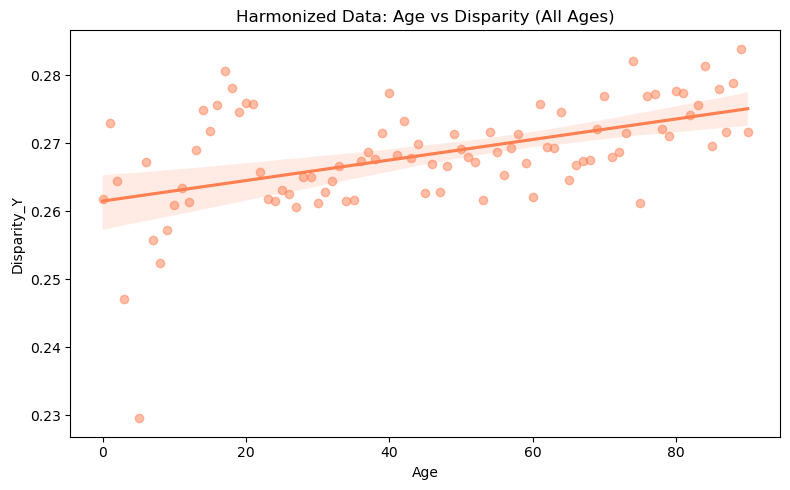

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(data_age_harm['age'], data_age_harm['Disparity_Y'], alpha=0.5, color='coral')
sns.regplot(x='age', y='Disparity_Y', data=data_age_harm, ax=ax, color='coral', scatter=False)
ax.set_title('Harmonized Data: Age vs Disparity (All Ages)')
ax.set_xlabel('Age')
ax.set_ylabel('Disparity_Y')
plt.tight_layout()
plt.show()

In [84]:
import pickle

data_harm.to_pickle('data_harm.pkl')
data_age_harm.to_pickle('data_age_harm.pkl')

np.savez_compressed('connectomes_harm_compressed.npz', connectomes=connectomes_harm)

c:\Users\Ale\Desktop\UB\NetLearn\proc_funcs.py:24: RuntimeWarning: invalid value encountered in divide
  nodal_Y = np.sum((adj / strength[:, None])**2, axis=1, where=valid[:, None])


    ROI         r         p_val   p_corrected  Significant
19  R20 -0.952716  2.173968e-13  1.956572e-11         True
69  R70 -0.918897  9.098245e-11  4.094210e-09         True
42  R43  0.884994  4.256789e-09  1.277037e-07         True
18  R19 -0.876056  9.618518e-09  1.410582e-07         True
66  R67  0.875744  9.884789e-09  1.410582e-07         True
37  R38  0.875734  9.894009e-09  1.410582e-07         True
68  R69 -0.874546  1.097119e-08  1.410582e-07         True
28  R29  0.852190  6.448626e-08  7.254704e-07         True
61  R62 -0.821001  4.957905e-07  4.714599e-06         True
67  R68  0.820066  5.238444e-07  4.714599e-06         True
34  R35 -0.790541  2.573245e-06  2.105382e-05         True
36  R37  0.775512  5.270162e-06  3.651466e-05         True
74  R75 -0.775495  5.274339e-06  3.651466e-05         True
1    R2 -0.773701  5.724592e-06  3.680095e-05         True
63  R64  0.770616  6.579908e-06  3.947945e-05         True


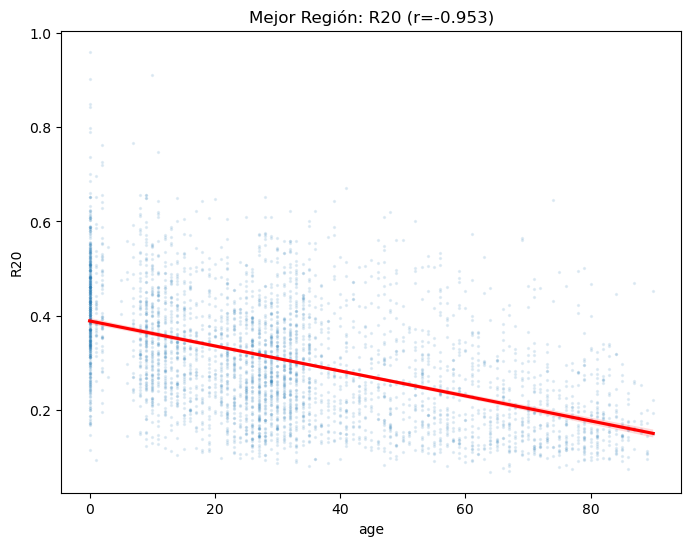

In [99]:
from proc_funcs import get_nodal_disparity_and_strength, run_roi_correlations
df_rois_disparities, df_rois_strengths = get_nodal_disparity_and_strength(connectomes_harm)

# Unimos con la edad y dataset de data_harm
df_full = pd.concat([data_harm[['age', 'dataset']], df_rois_disparities], axis=1)
#probar solo con jovenes
df_full_young = df_full[df_full['age'] <= 25]


results_young = run_roi_correlations(df_full_young, df_rois_disparities.columns, target_col='age', collapse_means=True)


winners = results_young[results_young['Significant'] == True]
print(winners.head(15))

# 7. Visualizar la mejor región
if not winners.empty:
    best_roi = winners.iloc[0]['ROI']
    r_val = winners.iloc[0]['r']
    
    plt.figure(figsize=(8, 6))
    sns.regplot(data=df_full, x='age', y=best_roi, scatter_kws={'alpha':0.1, 's':2}, line_kws={'color':'red'})
    plt.title(f"Mejor Región: {best_roi} (r={r_val:.3f})")
    plt.show()


In [100]:
#leave last column out
df_rois_disparities.columns

Index(['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10', 'R11',
       'R12', 'R13', 'R14', 'R15', 'R16', 'R17', 'R18', 'R19', 'R20', 'R21',
       'R22', 'R23', 'R24', 'R25', 'R26', 'R27', 'R28', 'R29', 'R30', 'R31',
       'R32', 'R33', 'R34', 'R35', 'R36', 'R37', 'R38', 'R39', 'R40', 'R41',
       'R42', 'R43', 'R44', 'R45', 'R46', 'R47', 'R48', 'R49', 'R50', 'R51',
       'R52', 'R53', 'R54', 'R55', 'R56', 'R57', 'R58', 'R59', 'R60', 'R61',
       'R62', 'R63', 'R64', 'R65', 'R66', 'R67', 'R68', 'R69', 'R70', 'R71',
       'R72', 'R73', 'R74', 'R75', 'R76', 'R77', 'R78', 'R79', 'R80', 'R81',
       'R82', 'R83', 'R84', 'R85', 'R86', 'R87', 'R88', 'R89', 'R90'],
      dtype='object')

✅ Atlas encontrado: ./preprocdata/aal-SPM12/aal/atlas/AAL.nii
📍 Coordenadas extraídas: 90 regiones.


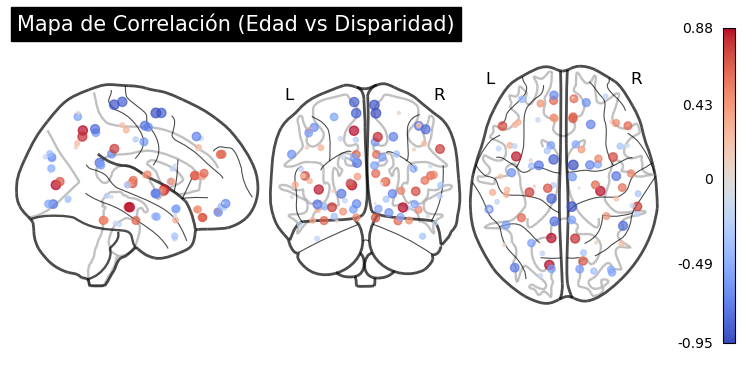

In [101]:
import os
from nilearn import plotting

carpeta_destino = './preprocdata/aal-SPM12/aal/atlas/'

ruta_atlas_nii = os.path.join(carpeta_destino, 'AAL.nii')

if not os.path.exists(ruta_atlas_nii):
    # A veces está dentro de una subcarpeta, ajusta esto si es necesario
    print(f"❌ No encuentro AAL.nii en {carpeta_destino}. Revisa la carpeta.")
else:
    print(f"✅ Atlas encontrado: {ruta_atlas_nii}")

    # 4. Extraer coordenadas LOCALMENTE (Sin internet)
    # nilearn lee el archivo .nii directamente del disco duro
    coords = plotting.find_parcellation_cut_coords(ruta_atlas_nii)
    
    # 5. Recortar a las primeras 90 regiones (AAL90)
    # El archivo original tiene 116 (incluye cerebelo)
    coords_90 = coords[:90]
    
    print(f"📍 Coordenadas extraídas: {len(coords_90)} regiones.")
    
    # 6. PINTAR EL CEREBRO (Usando tu vector de correlaciones 'r')
    # Asegúrate de tener 'r_values_vector' calculado del paso anterior
    
    plotting.plot_markers(
        node_values=results_young.set_index('ROI').loc[df_rois_disparities.columns]['r'].values, 
        node_coords=coords_90, 
        node_cmap='coolwarm',
        node_size=abs(results_young.set_index('ROI').loc[df_rois_disparities.columns]['r'].values)*50,
        title="Mapa de Correlación (Edad vs Disparidad)"
    )
    plt.show()

    ROI         r         p_val   p_corrected  Significant
19  R20 -0.925061  9.207574e-39  8.286817e-37         True
59  R60  0.848138  5.226724e-26  2.352026e-24         True
74  R75 -0.844658  1.308917e-25  3.926752e-24         True
4    R5  0.842479  2.298857e-25  5.172429e-24         True
77  R78 -0.817550  8.342388e-23  1.501630e-21         True
69  R70 -0.811923  2.788965e-22  4.183447e-21         True
18  R19 -0.805244  1.109478e-21  1.426471e-20         True
81  R82 -0.757522  5.582116e-18  6.130504e-17         True
73  R74  0.756927  6.130504e-18  6.130504e-17         True
68  R69 -0.734014  1.865613e-16  1.679052e-15         True
2    R3  0.719491  1.362342e-15  1.114644e-14         True
72  R73  0.718029  1.652962e-15  1.239721e-14         True
75  R76 -0.694610  3.121410e-14  2.160976e-13         True
5    R6  0.689578  5.660717e-14  3.639032e-13         True
83  R84 -0.683278  1.172720e-13  7.036321e-13         True


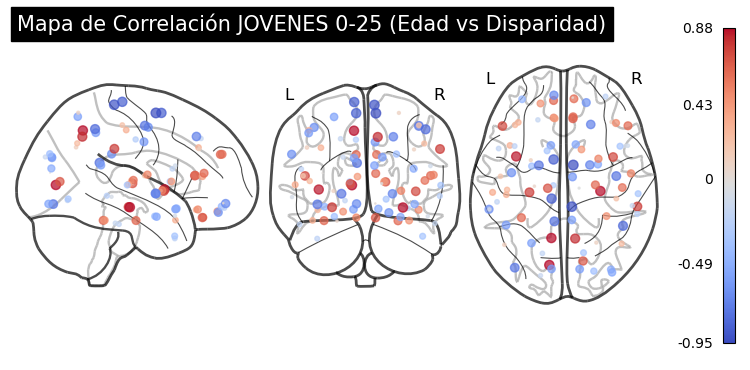

In [29]:
#probar solo con jovenes
df_full_young = df_full[df_full['age'] <= 25]

results_young = run_roi_correlations(df_full_young, df_rois.columns, target_col='age', collapse_means=True)

winners = results[results['Significant'] == True]
print(winners.head(15))

plotting.plot_markers(
        node_values=results_young.set_index('ROI').loc[df_rois.columns]['r'].values, 
        node_coords=coords_90, 
        node_cmap='coolwarm',
        node_size=abs(results_young.set_index('ROI').loc[df_rois.columns]['r'].values)*50,
        title="Mapa de Correlación JOVENES 0-25 (Edad vs Disparidad)"
    )
plt.show()


📊 Analizando contribución de 90 regiones...

--- VERDAD MATEMÁTICA ---
Promedio de pendientes individuales: 0.000139
Regiones que tiran hacia ARRIBA: 49
Regiones que tiran hacia ABAJO:  41
Fuerza media hacia ARRIBA:       0.000847
Fuerza media hacia ABAJO:        -0.000707


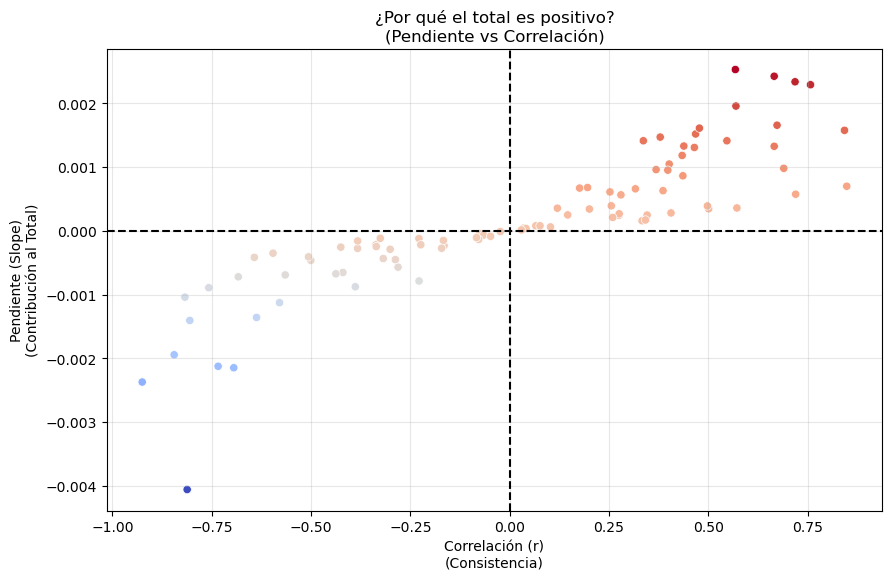

In [30]:
# Función para calcular pendiente (m) y correlación (r)
def get_slope_and_corr(x, y):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    return slope, r_value

# 1. Preparar datos
results_contribution = []
roi_cols = df_rois.columns.tolist()  # Use all ROI columns from df_rois

print(f"📊 Analizando contribución de {len(roi_cols)} regiones...")

# 2. Calcular Slope y R para cada región
for roi in roi_cols:
    # Usamos los datos promediados por edad como has hecho antes
    clean_data = df_full[['age', roi]].dropna().groupby('age').mean().reset_index()
    
    if len(clean_data) > 10:
        slope, r = get_slope_and_corr(clean_data['age'], clean_data[roi])
        results_contribution.append({
            'ROI': roi,
            'Slope': slope,   # Cuánto cambia Y por cada año (Magnitud)
            'Corr': r         # Qué tan consistente es (Forma)
        })

df_contrib = pd.DataFrame(results_contribution)

# 3. VERIFICACIÓN MATEMÁTICA
avg_slope = df_contrib['Slope'].mean()
print(f"\n--- VERDAD MATEMÁTICA ---")
print(f"Promedio de pendientes individuales: {avg_slope:.6f}")

# 4. ¿Quién gana? (Positivos vs Negativos)
positive_drivers = df_contrib[df_contrib['Slope'] > 0]
negative_drivers = df_contrib[df_contrib['Slope'] < 0]

print(f"Regiones que tiran hacia ARRIBA: {len(positive_drivers)}")
print(f"Regiones que tiran hacia ABAJO:  {len(negative_drivers)}")
print(f"Fuerza media hacia ARRIBA:       {positive_drivers['Slope'].mean():.6f}")
print(f"Fuerza media hacia ABAJO:        {negative_drivers['Slope'].mean():.6f}")

# 5. Visualización
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_contrib, x='Corr', y='Slope', hue='Slope', palette='coolwarm', legend=False)
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')
plt.title("¿Por qué el total es positivo?\n(Pendiente vs Correlación)")
plt.xlabel("Correlación (r)\n(Consistencia)")
plt.ylabel("Pendiente (Slope)\n(Contribución al Total)")
plt.grid(True, alpha=0.3)
plt.show()


In [31]:
disparities_harm = calculate_disparity(connectomes_harm)

data_harm = pd.DataFrame({
    'Subject': np.arange(connectomes_harm.shape[0]),
    'Disparity_Y': disparities_harm
})

data_harm = pd.concat([data_harm, demo_harm], axis=1)


✅ Cálculo terminado. Media Global Y: 0.2662


In [32]:
#select connectomes with highest and lowest disparity and export them as .dat files

extreme_disparities = np.argsort(disparities)
print("Sujetos con menor disparidad (Y):", extreme_disparities[0]) 
print("Sujetos con mayor disparidad (Y):", extreme_disparities[-1])
#Exportar los connectomas extremos a .dat
low_disp_connectome = connectomes_harm[extreme_disparities[0]] 
high_disp_connectome = connectomes_harm[extreme_disparities[-1]] 
np.savetxt('ESN/connectome_low_disparity.dat', low_disp_connectome, fmt='%.4f') 
np.savetxt('ESN/connectome_high_disparity.dat', high_disp_connectome, fmt='%.4f')

Sujetos con menor disparidad (Y): 514
Sujetos con mayor disparidad (Y): 1081


FileNotFoundError: [Errno 2] No such file or directory: 'ESN/connectome_low_disparity.dat'

In [ ]:
connectomes_harm.dtype

dtype('<f8')

In [ ]:
low_disp_connectome.shape
low_disp_connectome[0:5,0:5]

array([[0.        , 0.03156069, 0.        , 0.01648343, 0.        ],
       [0.03156069, 0.        , 0.        , 0.03823277, 0.        ],
       [0.        , 0.        , 0.        , 0.32084651, 0.        ],
       [0.01648343, 0.03823277, 0.32084651, 0.        , 0.08548224],
       [0.        , 0.        , 0.        , 0.08548224, 0.        ]])

In [ ]:
from Graph import Graph
import networkx as nx

low_disp_connectome.dtype
low_disp_connectome.shape



# 2. Función auxiliar para convertir Matrix -> Tu Clase Graph
def matrix_to_nx(matrix, roi_labels=df_rois.columns):
    # A) Convertir numpy a NetworkX (preserva pesos en 'weight')
    nx_g = nx.from_numpy_array(matrix)
    mapping = {i: name for i, name in enumerate(roi_labels)}
    nx_g = nx.relabel_nodes(nx_g, mapping)
    
    # C) Instanciar TU clase
    return Graph(nx_g)


graph_low = matrix_to_nx(low_disp_connectome)
graph_high = matrix_to_nx(high_disp_connectome)

graph_low.describe_graph()
graph_high.describe_graph()


nx.write_gexf(graph_low.G, "ESN/graph_low_disparity.gexf")
nx.write_gexf(graph_high.G, "ESN/graph_high_disparity.gexf")


Graph: 90 nodes, 401 edges


Graph: 90 nodes, 402 edges



In [ ]:
nx.adjacency_matrix(graph_low.G)


<Compressed Sparse Row sparse array of dtype 'float64'
	with 802 stored elements and shape (90, 90)>

In [ ]:
# Comprobación rápida: ¿Sube Y pero baja la Fuerza?
data_harm['Strength'] = [np.sum(c) for c in connectomes_harm]
print("Correlación Edad vs Strength:", stats.pearsonr(data_harm['age'], data_harm['Strength']))

Correlación Edad vs Strength: PearsonRResult(statistic=0.4413848134087408, pvalue=4.600701253333959e-181)


In [ ]:
# Comprobar Strength SOLO en Adultos (>25 años)
data_harm['Strength'] = [np.sum(c) for c in connectomes_harm] # Recalculamos por si acaso

df_old = data_harm[data_harm['age'] > 25]
r_str_old, p_str_old = stats.pearsonr(df_old['age'], df_old['Strength'])

print(f"Strength en Adultos (25-90): r = {r_str_old:.4f}, p = {p_str_old:.4e}")

Strength en Adultos (25-90): r = 0.3254, p = 4.8339e-54


In [33]:
# Comprobar Strength SOLO en Adultos (>25 años)
data_harm['Strength'] = [np.sum(c) for c in connectomes_harm] # Recalculamos por si acaso

df_young = data_harm[data_harm['age'] < 25]
r_str_young, p_str_young = stats.pearsonr(df_young['age'], df_young['Strength'])

print(f"Strength en Jóvenes (<25): r = {r_str_young:.4f}, p = {p_str_young:.4e}")

Strength en Jóvenes (<25): r = 0.1166, p = 3.3096e-06


Densidad en Adultos: r = -0.0238


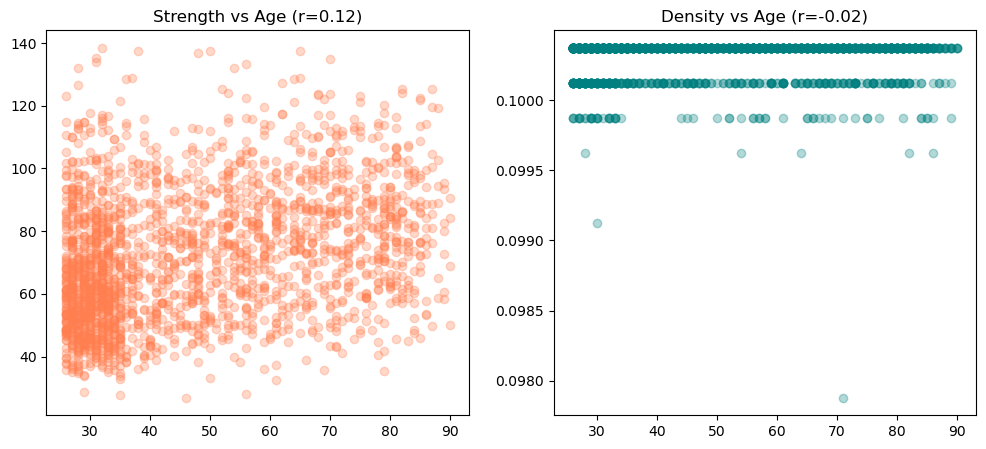

In [128]:
import matplotlib.pyplot as plt
from scipy import stats

# 1. Calcular Densidad (Porcentaje de conexiones que NO son 0)
# Asumimos que la diagonal ya es 0
n_nodes = connectomes_harm.shape[1]
max_edges = n_nodes * (n_nodes - 1) # Grafo dirigido o n*(n-1)/2 si no dirigido

densities = []
for matrix in connectomes_harm:
    n_edges = np.count_nonzero(matrix)
    densities.append(n_edges / max_edges)

data_harm['Density'] = densities

# 2. Correlacionar Edad vs Densidad en Adultos
df_old = data_harm[data_harm['age'] > 25]
r_dens, p_dens = stats.pearsonr(df_old['age'], df_old['Density'])

print(f"Densidad en Adultos: r = {r_dens:.4f}")

# 3. Plotear para entender
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Strength vs Age
ax[0].scatter(df_old['age'], df_old['Strength'], alpha=0.3, color='coral')
ax[0].set_title(f"Strength vs Age (r={r_str_old:.2f})")

# Density vs Age
ax[1].scatter(df_old['age'], df_old['Density'], alpha=0.3, color='teal')
ax[1].set_title(f"Density vs Age (r={r_dens:.2f})")

plt.show()

In [129]:
# Calcular Densidad para cada sujeto: (Nº conexiones reales / Nº conexiones posibles)
# Asumimos grafos no dirigidos: n*(n-1)/2 posibles
n_nodes = connectomes_harm.shape[1]
max_edges = n_nodes * (n_nodes - 1) 

densities = []
for matrix in connectomes_harm:
    # Contar cuántos elementos no son 0 (y restar la diagonal si no es 0)
    n_edges = np.count_nonzero(matrix) 
    densities.append(n_edges / max_edges)

data_harm['Density'] = densities

# Correlación Edad vs Densidad en ADULTOS
df_old = data_harm[data_harm['age'] > 25]
r_dens, p_dens = stats.pearsonr(df_old['age'], df_old['Density'])

print(f"Densidad en Adultos: r = {r_dens:.4f}")

Densidad en Adultos: r = -0.0238
